In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(23)

In [3]:
mu_vec1 = np.array([0,0,0])

In [5]:
mu_vec1

array([0, 0, 0])

In [7]:
cov_mat1 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

In [8]:
class1_sample = np.random.multivariate_normal(
    mu_vec1,
    cov_mat1,
    20
)

In [9]:
df = pd.DataFrame(
    class1_sample,
    columns=["feature1","feature2","feature3"]
)

In [10]:
df["Target"] = 1

In [11]:
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

class2_sample = np.random.multivariate_normal(
    mu_vec2,
    cov_mat2,
    20
)

df1 = pd.DataFrame(
    class2_sample,
    columns=["feature1","feature2","feature3"]
)


df1["Target"] = 0

In [16]:
df = pd.concat([df, df1], ignore_index=True)

In [18]:
df.sample(10)

,feature1,feature2,feature3,Target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1
29,1.425140,1.441152,0.182561,0
31,2.224431,0.230401,1.192120,0
4,0.322272,0.060343,-1.043450,1
32,-0.723253,1.461259,-0.085367,0
33,2.823378,-0.332863,2.637391,0


In [20]:
import plotly.express as px

fig = px.scatter_3d(

                    df,
                    x="feature1",
                    y="feature2",
                    z="feature3",
                    color=df["Target"].astype(str)
)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color="DarkSlateGrey")),
                  selector=dict(mode='markers'))

fig.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [22]:
covarience_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print("covarience matrix : \n", covarience_matrix)

covarience matrix : 
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [24]:
eigen_values,eigen_vector = np.linalg.eig(covarience_matrix)

In [25]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [26]:
eigen_vector

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

Populating the interactive namespace from numpy and matplotlib


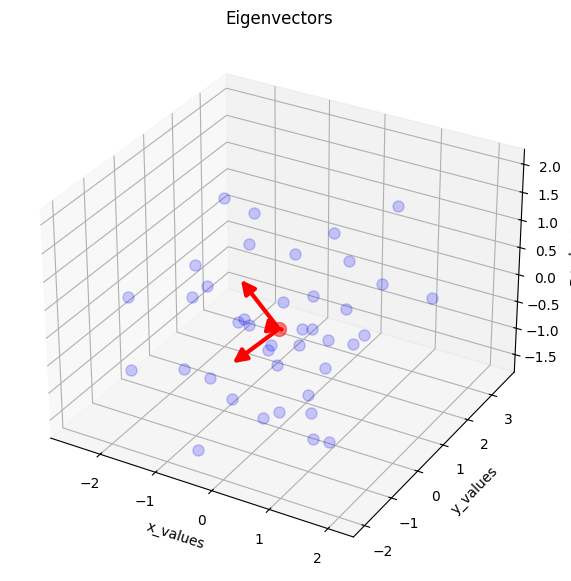

In [32]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self):
        xs3d, ys3d, zs3d = self._verts3d
        _, _, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        return np.min(zs)


fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    'o',
    markersize=8,
    color='blue',
    alpha=0.2
)

ax.plot(
    [df['feature1'].mean()],
    [df['feature2'].mean()],
    [df['feature3'].mean()],
    'o',
    markersize=10,
    color='red',
    alpha=0.5
)

for v in eigen_vector.T:
    a = Arrow3D(
        [df['feature1'].mean(), v[0]],
        [df['feature2'].mean(), v[1]],
        [df['feature3'].mean(), v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')
plt.show()

In [37]:
pc = eigen_vector[:,0:2]
pc

pc.shape

(3, 2)

In [40]:
transformed_df = np.dot(df.iloc[:,0:3],pc)

new_df = pd.DataFrame(transformed_df,columns=["Pc1","Pc2"])
new_df["target"] = df["Target"].values
new_df.head()

,Pc1,Pc2,target
0,0.833918,-1.052194,1
1,0.404984,-1.403021,1
2,2.302877,-0.757593,1
3,-0.125711,-0.802324,1
4,1.098223,-1.011722,1


In [41]:
new_df

,Pc1,Pc2,target
0,0.833918,-1.052194,1
1,0.404984,-1.403021,1
2,2.302877,-0.757593,1
3,-0.125711,-0.802324,1
4,1.098223,-1.011722,1
5,0.477943,1.168024,1
6,2.350916,0.841828,1
7,-0.403777,-0.280393,1
8,1.349328,-0.377883,1
9,0.665521,-1.699993,1


In [42]:
import plotly.express as px

fig = px.scatter(
    new_df,
    x="Pc1",
    y="Pc2",
    color="target"
)

fig.show()




In [44]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['Pc1'],
                 y=new_df['Pc2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [45]:
pc1 = eigen_vector[:,0:1]
pc1

pc1.shape

(3, 1)

In [47]:
transformed_df = np.dot(df.iloc[:,0:3],pc1)
# 40,3 - 3,1 dot product means 3 3 gaya 40,1 bacha points transformation
new_df1 = pd.DataFrame(transformed_df,columns=['PC1'])
new_df1['target'] = df['Target'].values
new_df1.head()

,PC1,target
0,0.833918,1
1,0.404984,1
2,2.302877,1
3,-0.125711,1
4,1.098223,1


In [53]:
import plotly.express as px

fig = px.scatter(
    new_df1,
    x="PC1",
    color="target"
)

fig.show()
